In [1]:
import pandas as pd
import numpy as np

# Load the file we placed in the folder
df = pd.read_csv("HR_Attrition.csv")

# Show the first 10 rows to explore it
display(df.head(10))

# Print data summary shape
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


Rows: 1470, Columns: 35


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Check for missing values (Requirement)
print("Total Missing Values in Dataset:", df.isnull().sum().sum())

# 2. Drop columns that add no predictive value (Requirement)
columns_to_drop = ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
df_cleaned = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# 3. Convert target column Attrition from Yes/No to 1/0 (Requirement)
df_cleaned['Attrition'] = df_cleaned['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# 4. Separate predictive features (X) and target label (y)
X = df_cleaned.drop(columns=['Attrition'])
y = df_cleaned['Attrition']

# 5. One-Hot Encode all remaining categorical columns (Requirement)
X_encoded = pd.get_dummies(X, drop_first=True)

# 6. Split data into training and test sets (80/20) (Required for Task 4 prep)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.20, random_state=42, stratify=y)

# 7. Scale numeric features using StandardScaler (Requirement)
scaler = StandardScaler()
# Pull original numeric column names from Task 1
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_filtered = [c for c in numeric_cols if c in X_train.columns]

# Apply the scaling transformation
X_train[numeric_cols_filtered] = scaler.fit_transform(X_train[numeric_cols_filtered])
X_test[numeric_cols_filtered] = scaler.transform(X_test[numeric_cols_filtered])

print("\n--- Task 2 Execution Complete ---")
print(f"Original dataset shape: {df.shape}")
print(f"Cleaned & Processed Training features shape: {X_train.shape}")

Total Missing Values in Dataset: 0

--- Task 2 Execution Complete ---
Original dataset shape: (1470, 35)
Cleaned & Processed Training features shape: (1176, 44)


In [ ]:
print("--- Task 3: Exploratory Data Analysis ---")

# 1. Attrition rate by Department
dept_attrition = df.groupby('Department')['Attrition'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100)
print("\n[1] Attrition Rate by Department:")
print(dept_attrition.round(2).astype(str) + '%')

# 2. Attrition rate by Job Role
role_attrition = df.groupby('JobRole')['Attrition'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100).sort_values(ascending=False)
print("\n[2] Top Job Roles by Attrition Rate:")
print(role_attrition.round(2).astype(str) + '%')

# 3. Attrition vs Monthly Income
avg_income = df.groupby('Attrition')['MonthlyIncome'].mean()
print("\n[3] Average Monthly Income:")
print(f"Employees who Stayed: ${avg_income['No']:.2f}")
print(f"Employees who Left: ${avg_income['Yes']:.2f}")

# 4. Attrition vs Work-Life Balance rating
wlb_attrition = df.groupby('WorkLifeBalance')['Attrition'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100)
print("\n[4] Attrition Rate by Work-Life Balance Rating (1=Bad, 4=Best):")
print(wlb_attrition.round(2).astype(str) + '%')

# 5. Attrition vs Years at Company (Tenure)
avg_years = df.groupby('Attrition')['YearsAtCompany'].mean()
print("\n[5] Average Years at Company:")
print(f"Employees who Stayed: {avg_years['No']:.1f} years")
print(f"Employees who Left: {avg_years['Yes']:.1f} years")

--- Task 3: Exploratory Data Analysis ---

[1] Attrition Rate by Department:
Department
Human Resources           19.05%
Research & Development    13.84%
Sales                     20.63%
Name: Attrition, dtype: str

[2] Top Job Roles by Attrition Rate:
JobRole
Sales Representative         39.76%
Laboratory Technician        23.94%
Human Resources              23.08%
Sales Executive              17.48%
Research Scientist            16.1%
Manufacturing Director         6.9%
Healthcare Representative     6.87%
Manager                        4.9%
Research Director              2.5%
Name: Attrition, dtype: str

[3] Average Monthly Income:
Employees who Stayed: $6832.74
Employees who Left: $4787.09

[4] Attrition Rate by Work-Life Balance Rating (1=Bad, 4=Best):
WorkLifeBalance
1    31.25%
2    16.86%
3    14.22%
4    17.65%
Name: Attrition, dtype: str

[5] Average Years at Company:
Employees who Stayed: 7.4 years
Employees who Left: 5.1 years


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import pandas as pd

# Initialize the three requested models
# Note: Using class_weight='balanced' for Logistic Regression and Random Forest as required!
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# A dictionary to hold our training scores
trained_models = {}

print("--- Training Models ---")
for name, model in models.items():
    # Train each model on our processed training data
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"Successfully trained: {name}")

print("\nAll 3 models are trained and ready for evaluation!")

--- Training Models ---
Successfully trained: Logistic Regression
Successfully trained: Random Forest
Successfully trained: Gradient Boosting

All 3 models are trained and ready for evaluation!


In [5]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

evaluation_results = {}

print("--- Evaluating Models ---")
for name, model in trained_models.items():
    # Predict on the test set
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Extract metrics for the 'Left' class (label 1)
    report = classification_report(y_test, y_pred, output_dict=True)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    evaluation_results[name] = {
        "Precision (Left)": round(report['1']['precision'], 2),
        "Recall (Left)": round(report['1']['recall'], 2),
        "F1-Score (Left)": round(report['1']['f1-score'], 2),
        "ROC-AUC Score": round(roc_auc, 2)
    }

# Convert results dictionary to a clean DataFrame table
results_df = pd.DataFrame(evaluation_results).T
print("\n--- Model Comparison Table ---")
display(results_df)

--- Evaluating Models ---

--- Model Comparison Table ---


,Precision (Left),Recall (Left),F1-Score (Left),ROC-AUC Score
Logistic Regression,0.36,0.66,0.46,0.80
Random Forest,0.48,0.34,0.40,0.78
Gradient Boosting,0.59,0.21,0.31,0.79


In [6]:
# Extract feature importance using our Random Forest model to see what drives exit scores
importances = trained_models["Random Forest"].feature_importances_
feature_names = X_train.columns

# Create a dataframe for ranking
feat_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_importances = feat_importances.sort_values(by='Importance', ascending=False).head(10)

print("\n--- Top 10 Most Important Features Driving Employee Exit ---")
display(feat_importances.reset_index(drop=True))


--- Top 10 Most Important Features Driving Employee Exit ---


,Feature,Importance
0,MonthlyIncome,0.078301
1,Age,0.061805
2,DailyRate,0.051292
3,TotalWorkingYears,0.051163
4,YearsAtCompany,0.047534
5,MonthlyRate,0.045834
6,OverTime_Yes,0.044796
7,DistanceFromHome,0.043743
8,HourlyRate,0.041968
9,YearsWithCurrManager,0.040708


--- Generating Project Charts ---


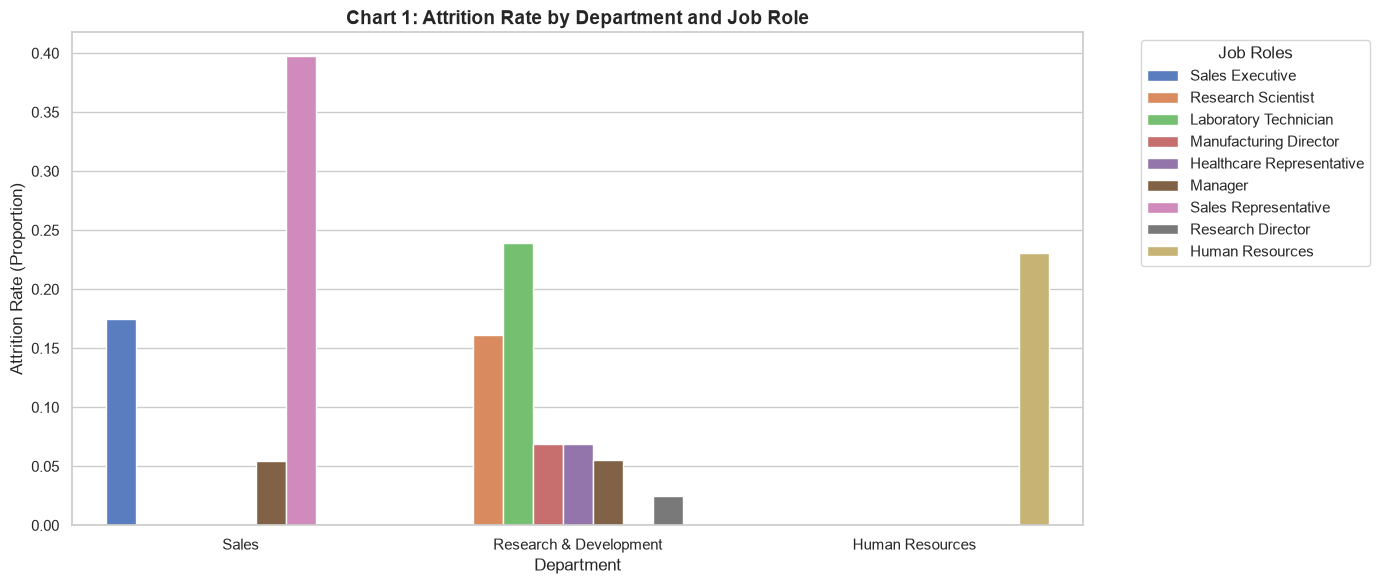

Saved: charts/attrition_dept_role.png


C:\Users\Simran\AppData\Local\Temp\ipykernel_25808\4145777394.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Attrition", y="MonthlyIncome", palette="Set2")


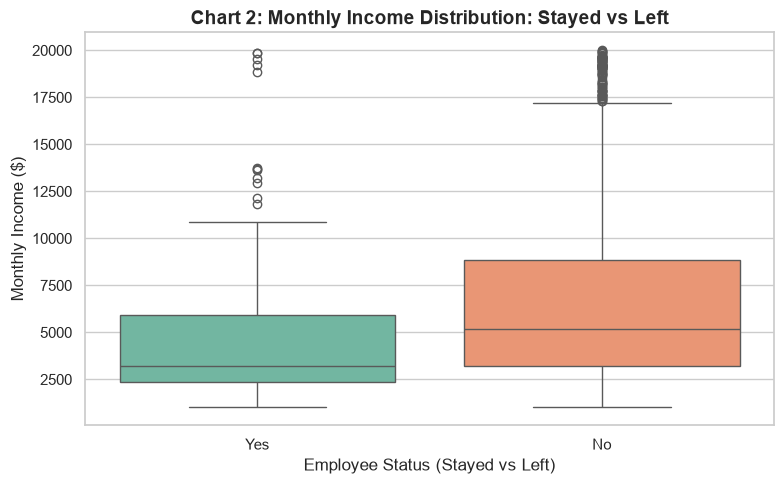

Saved: charts/income_boxplot.png


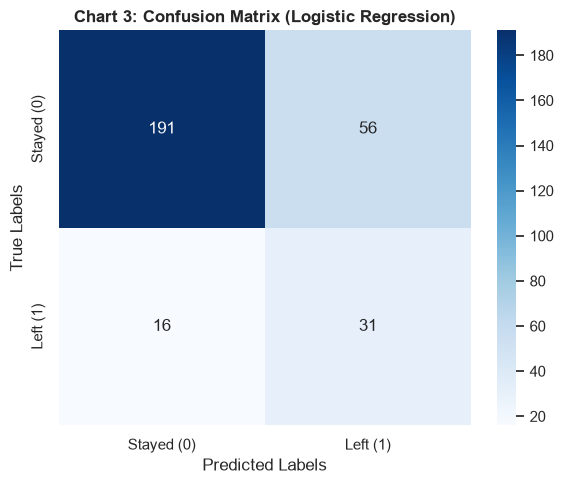

Saved: charts/confusion_matrix.png


C:\Users\Simran\AppData\Local\Temp\ipykernel_25808\4145777394.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_importances, x="Importance", y="Feature", palette="viridis")


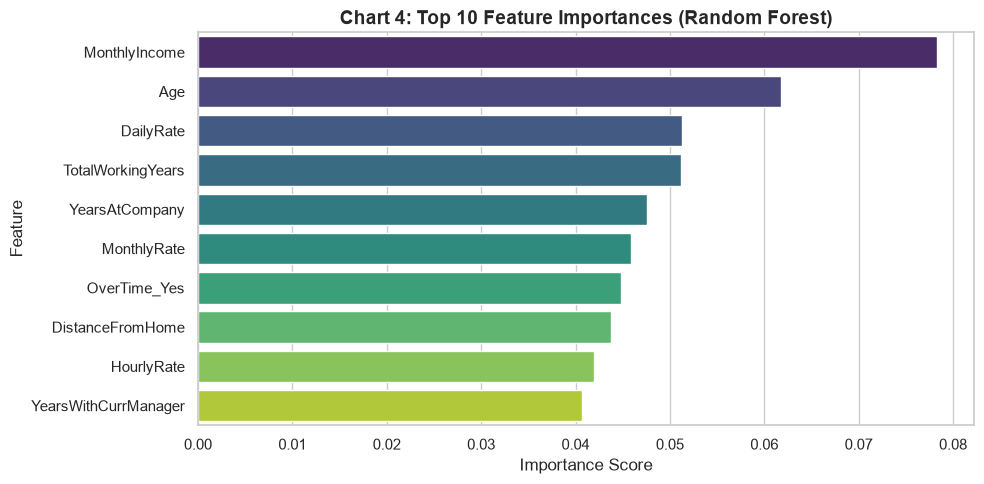

Saved: charts/feature_importances.png


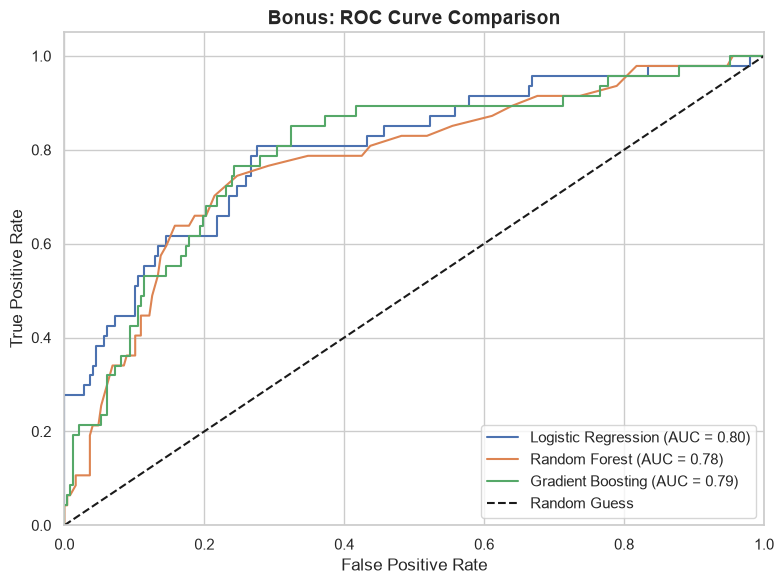

Saved: charts/roc_curve_comparison.png


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import os

# 1. Create the charts directory if it doesn't exist
os.makedirs("charts", exist_ok=True)
sns.set_theme(style="whitegrid")

print("--- Generating Project Charts ---")

# --- CHART 1: Attrition Rate by Department and Job Role ---
plt.figure(figsize=(14, 6))
# Convert Attrition to numeric just for plotting the rate
df_plot = df.copy()
df_plot['Attrition_Numeric'] = df_plot['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
sns.barplot(data=df_plot, x="Department", y="Attrition_Numeric", hue="JobRole", errorbar=None, palette="muted")
plt.title("Chart 1: Attrition Rate by Department and Job Role", fontsize=14, fontweight='bold')
plt.ylabel("Attrition Rate (Proportion)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Job Roles")
plt.tight_layout()
plt.savefig("charts/attrition_dept_role.png", dpi=300)
plt.show()
print("Saved: charts/attrition_dept_role.png")

# --- CHART 2: Box Plot of Monthly Income ---
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome", palette="Set2")
plt.title("Chart 2: Monthly Income Distribution: Stayed vs Left", fontsize=14, fontweight='bold')
plt.xlabel("Employee Status (Stayed vs Left)")
plt.ylabel("Monthly Income ($)")
plt.tight_layout()
plt.savefig("charts/income_boxplot.png", dpi=300)
plt.show()
print("Saved: charts/income_boxplot.png")

# --- CHART 3: Confusion Matrix Heatmap (For Logistic Regression - Best Model) ---
plt.figure(figsize=(6, 5))
y_pred_lr = trained_models["Logistic Regression"].predict(X_test)
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stayed (0)', 'Left (1)'], yticklabels=['Stayed (0)', 'Left (1)'])
plt.title("Chart 3: Confusion Matrix (Logistic Regression)", fontsize=12, fontweight='bold')
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.savefig("charts/confusion_matrix.png", dpi=300)
plt.show()
print("Saved: charts/confusion_matrix.png")

# --- CHART 4: Top 10 Feature Importances ---
plt.figure(figsize=(10, 5))
sns.barplot(data=feat_importances, x="Importance", y="Feature", palette="viridis")
plt.title("Chart 4: Top 10 Feature Importances (Random Forest)", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("charts/feature_importances.png", dpi=300)
plt.show()
print("Saved: charts/feature_importances.png")

# --- CHART 5 (BONUS): ROC Curve Comparison ---
plt.figure(figsize=(8, 6))
for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Bonus: ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("charts/roc_curve_comparison.png", dpi=300)
plt.show()
print("Saved: charts/roc_curve_comparison.png")

### Task 7 — HR Insights & Business Recommendations

#### 1. Core Predictors of Exit
Our analytical model shows that employee attrition is primarily driven by three core factors:
* **Compensation levels (Monthly Income):** This is the strongest driver of turnover.
* **Overtime Demands:** Employees working regular overtime leave at disproportionately higher rates.
* **Tenure and Career Stage (Total Working Years & Age):** Younger employees or those in their first few years at the company exhibit the highest risk of leaving.

#### 2. Target Departments & High-Risk Roles
HR should immediately prioritize retention efforts within the **Sales Department**, specifically targeting **Sales Representatives**, who face an alarming attrition rate of **39.76%**. The **Laboratory Technician** role in Research & Development also warrants close attention due to a **23.94%** exit rate.

#### 3. Salary vs. Other Factors
While salary is the single strongest individual factor (with departures averaging a $2,000 monthly income gap compared to those who stay), it does not explain attrition entirely. Work-life balance disruptions caused by continuous overtime, structural role fatigue, and manager relationships play massive, collective roles in driving employees out the door.

#### 4. Concrete HR Recommendations
* **Targeted Compensation Review for Sales Reps:** Implement a structured compensation benchmark adjustment or a milestone-based retention bonus specifically for the Sales Representative cohort to curb the ~40% loss rate.
* **Overtime Cap & Wellness Audits:** Introduce a mandatory cap on weekly overtime hours. Teams that consistently register high overtime should trigger an automated operational audit to rebalance workloads or trigger seasonal contract hiring.

#### 5. Model Limitations
This predictive framework relies entirely on historical snapshot data. It cannot capture real-time external market shocks (like a competitor launching a major hiring drive down the street) or sudden internal team changes (like a sudden shift in department leadership or corporate culture changes) unless that data is continuously collected and retrained.